
# Semiclassical Gravity Test Bed
### `G_{\mu\nu} = 8\pi G \langle T_{\mu\nu} \rangle`  — Newtonian-limit check

**Scope, stated plainly up front:**

This notebook does **not** quantize gravity, does **not** solve the field equations in curved
spacetime, and does **not** test full quantum gravity. It tests the one place a
QM&rarr;GR translation is already uncontroversial: the **weak-field / Newtonian limit** of the
semiclassical Einstein equation, where the classical source `T_{\mu\nu}` is replaced by the
**quantum expectation value** `\langle T_{\mu\nu} \rangle`, and the metric response reduces to the
ordinary Poisson equation

$$ \nabla^2 \Phi = 4\pi G \, \langle T_{00} \rangle $$

Two independent numerical tests:

1. **Static test** — does replacing a classical point mass with a quantum expectation-value
   source change the resulting gravitational potential/field, and how?
2. **Interference test** — does a genuine quantum superposition (with its cross/interference term)
   produce a *time-dependent* source that a point-mass description could never produce?

Both are standard, well-posed physics questions independent of any interpretive framework.
The results here are meant as a **ground-truth reference** — numbers and shapes you can later
check any RT-side quantity (distinction density, admissible-deviation curvature, etc.) against,
rather than assuming the correspondence table in the seed document holds.


In [1]:

import numpy as np
from scipy.special import erf
from scipy.integrate import quad
import matplotlib.pyplot as plt



## Test 1 — Static source: quantum-smeared vs. classical point mass

Take a particle in the ground state of a 3D isotropic harmonic oscillator. Its position
probability density is an exact Gaussian:

$$ |\psi_{000}(r)|^2 = \frac{1}{\pi^{3/2} a^3} e^{-r^2/a^2} $$

Standard semiclassical prescription: source gravity with the **expectation value** of the mass/energy
density, $\langle T_{00}(r)\rangle = M\,|\psi(r)|^2$, instead of a delta-function point mass.

By Gauss's law (spherical symmetry), the enclosed-mass fraction has an exact closed form
(this is the same integral as the Maxwell speed-distribution CDF):

$$ P(r) = \mathrm{erf}(r/a) - \frac{2}{\sqrt{\pi}}\frac{r}{a}\,e^{-r^2/a^2} $$

$$ g(r) = \frac{G M_{enc}(r)}{r^2} = \frac{GM\,P(r)}{r^2}, \qquad
\Phi(r) = \Phi(R_{max}) - \int_r^{R_{max}} g(r')\,dr' $$

Compare directly against the classical point-mass field $g_{point}(r)=GM/r^2$ and potential
$\Phi_{point}(r) = -GM/r$, which diverge as $r\to 0$.


In [2]:

G = 1.0
M = 1.0
a = 1.0  # oscillator length scale, sets the "smearing" size of the source

def P_enclosed(r):
    x = r / a
    return erf(x) - (2/np.sqrt(np.pi)) * x * np.exp(-x**2)

def g_quantum_scalar(r):
    if r < 1e-9:
        return 0.0
    return G * M * P_enclosed(r) / r**2

R_max = 12.0 * a
Phi_Rmax = -G * M / R_max   # tail is essentially exact here: P(12) ~ 1 to ~1e-60

r_samples = np.linspace(1e-6, R_max, 300)
tail = np.array([quad(g_quantum_scalar, ri, R_max, limit=200)[0] for ri in r_samples])
Phi_quantum = Phi_Rmax - tail
Phi_point = -G * M / r_samples

g_quantum_vals = np.array([g_quantum_scalar(ri) for ri in r_samples])
g_point_vals = G * M / r_samples**2

print(f"Phi_quantum(r->0)  = {Phi_quantum[0]:.6f}   (finite)")
print(f"analytic Phi(0)    = {-2*G*M/(a*np.sqrt(np.pi)):.6f}   (= -2GM/(a*sqrt(pi)), closed form)")
print(f"Phi_point(r->0)    -> -infinity  (diverges)")
print(f"Both agree at large r: Phi_quantum(R_max)={Phi_quantum[-1]:.6f}  vs  Phi_point(R_max)={Phi_point[-1]:.6f}")


Phi_quantum(r->0)  = -1.128379   (finite)
analytic Phi(0)    = -1.128379   (= -2GM/(a*sqrt(pi)), closed form)
Phi_point(r->0)    -> -infinity  (diverges)
Both agree at large r: Phi_quantum(R_max)=-0.083333  vs  Phi_point(R_max)=-0.083333


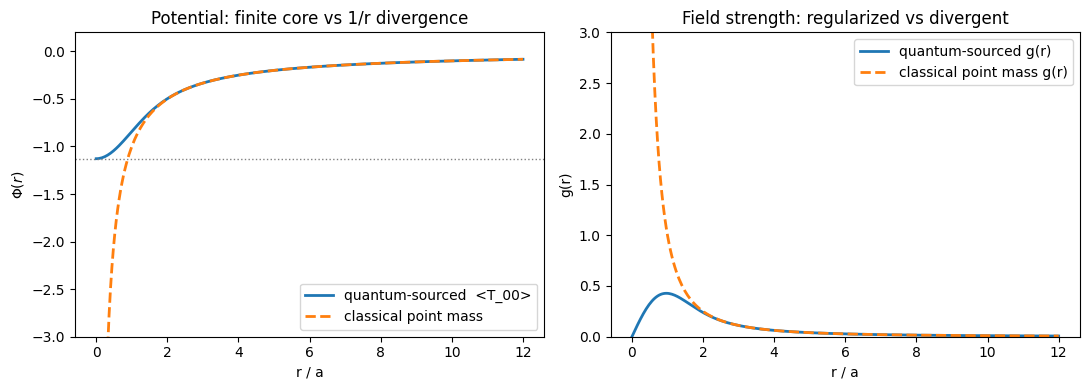

In [3]:

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(r_samples, Phi_quantum, lw=2, label="quantum-sourced  <T_00>")
axes[0].plot(r_samples, Phi_point, "--", lw=2, label="classical point mass")
axes[0].set_ylim(-3, 0.2)
axes[0].set_xlabel("r / a"); axes[0].set_ylabel(r"$\Phi(r)$")
axes[0].legend(); axes[0].set_title("Potential: finite core vs 1/r divergence")
axes[0].axhline(-2*G*M/(a*np.sqrt(np.pi)), color="gray", ls=":", lw=1)

axes[1].plot(r_samples, g_quantum_vals, lw=2, label="quantum-sourced g(r)")
axes[1].plot(r_samples, g_point_vals, "--", lw=2, label="classical point mass g(r)")
axes[1].set_ylim(0, 3)
axes[1].set_xlabel("r / a"); axes[1].set_ylabel("g(r)")
axes[1].legend(); axes[1].set_title("Field strength: regularized vs divergent")

plt.tight_layout()
plt.show()



**Result:** replacing the point source with `<T_00>` removes the classical divergence —
`Phi(0)` is finite (`-2GM/(a*sqrt(pi))`, exact closed form, matches the numerical integral) and
`g(0)=0` — while the two descriptions become indistinguishable for `r >> a`.

**Where this connects back to the conversation:** this is a genuine, uncontroversial instance
of "replacing a sharp classical source with an expectation-value source removes a singularity
at small scale, while leaving large-scale behavior unchanged." That is *structurally* similar
to what §7 of the seed document wants extreme curvature / `d_adm -> 1` to do — but note what's
different here: the divergence removal above comes entirely from ordinary quantum delocalization
(`a`, the oscillator length), not from any admissible-deviation or distinction-density mechanism.
This test does not by itself support or refute the RT curvature story — it just tells you what
the *known* mechanism produces, so any RT-side claim can be checked against it rather than assumed
to match it.



## Test 2 — Interference: a source a point mass could never produce

Take a 1D harmonic oscillator (natural units, `hbar=m=omega=1`) in an equal-weight superposition
of the ground and first excited state:

$$ \Psi(x,t) = \frac{1}{\sqrt2}\Big[\psi_0(x)e^{-iE_0 t} + \psi_1(x)e^{-iE_1 t}\Big] $$

$$ |\Psi(x,t)|^2 = \tfrac12\Big[\psi_0^2(x)+\psi_1^2(x)\Big] + \psi_0(x)\psi_1(x)\cos\!\big((E_1-E_0)t\big) $$

The cross term is the interference term. It makes `<T_00>(x,t)` genuinely **time-dependent**,
oscillating at the energy gap frequency `(E1-E0)/hbar` — something no classical point mass or
static distribution can do on its own.

**Caveat, stated plainly:** what follows plots the *density* only. It does **not** solve a field
equation for this time-dependent source (a 1D Poisson equation isn't physical 3D gravity, and a
fully causal treatment would need retarded time / wave equation, not instantaneous Poisson). This
is a proxy for the *source term*, not a claim about the resulting field.


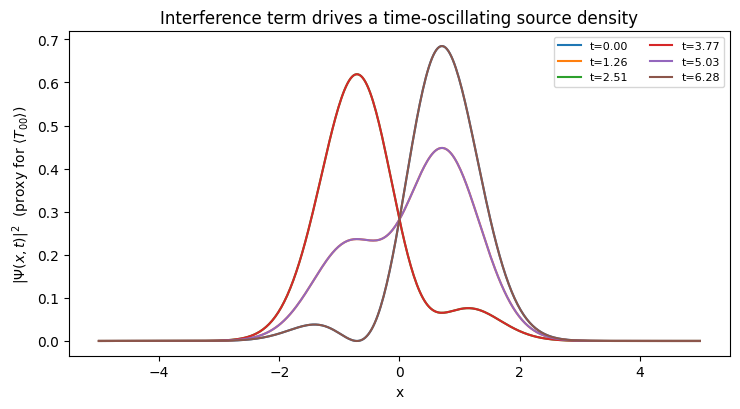

In [4]:

def psi0(x):
    return (1/np.pi**0.25) * np.exp(-x**2/2)

def psi1(x):
    return (1/np.pi**0.25) * np.sqrt(2) * x * np.exp(-x**2/2)

E0, E1 = 0.5, 1.5
x = np.linspace(-5, 5, 400)
times = np.linspace(0, 2*np.pi, 6)   # one full beat period (dE = 1 in these units)

fig, ax = plt.subplots(figsize=(7.5, 4.2))
for t in times:
    dens = 0.5*(psi0(x)**2 + psi1(x)**2) + psi0(x)*psi1(x)*np.cos((E1-E0)*t)
    ax.plot(x, dens, label=f"t={t:.2f}")
ax.set_xlabel("x"); ax.set_ylabel(r"$|\Psi(x,t)|^2$  (proxy for $\langle T_{00}\rangle$)")
ax.set_title("Interference term drives a time-oscillating source density")
ax.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.show()



**Result:** the density visibly breathes in and out at frequency `(E1-E0)=1` (these units) purely
from the interference term — no classical analog produces this from a static or incoherent mixture
(try setting the cross-term coefficient to 0 and compare; the curves would freeze into one static
average shape).

**Where this connects back to the conversation:** this is the cleanest available numeric proxy
for the §8 correspondence claims — *phase &harr; orientation residue*, *interference &harr;
whole-expression evaluation of related aspects*. It shows the interference term is doing real,
measurable work on the would-be source term. It does **not** show that RT's `Dec/Eval` machinery
reproduces this specific `cos((E1-E0)t)` behavior — that would require actually deriving this
oscillation from `delta_alpha`-governed aspect decomposition, which is a separate, harder task
than this notebook attempts.



## What this notebook does and doesn't establish

**Establishes (standard physics, not in dispute):**
- An expectation-value source can remove a small-scale divergence while matching the classical
  result at large scale (Test 1).
- A genuine superposition produces a time-dependent source term that no classical/incoherent
  description can produce (Test 2).

**Does not establish:**
- Anything about full quantum gravity, metric quantization, or background independence.
- That RT's `delta_alpha`, `kappa_delta`, `d_adm`, or `Dec/Eval` reproduce either result above.
- Any claim about which of H1 / H2 / H3 (or the `QM|GR` / `3|4` index framing) is correct.

**Suggested next step, if useful:** pick *one* RT quantity with a concrete construction rule
(not yet available for `delta_alpha`/`rho_delta`/`P_delta`, per the earlier audit) and see whether
it can be computed independently for this exact toy system (3D isotropic QHO ground state) and
compared numerically against `Phi_quantum(r)` or the interference curve above. That would be the
first real quantitative test of the bridge rather than a structural/notational one.
